In [2]:
import sys, os, json
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import build_preprocessor, feature_names, ALL_FEATURES
from src.feature_selection import run_all

sns.set_theme(style="whitegrid")

X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")["_MICHD"]

prep = build_preprocessor()
A_train = prep.fit_transform(X_train[ALL_FEATURES])
names = feature_names(prep)
print(A_train.shape)         

(361971, 87)


In [3]:
scores, ranks, summary = run_all(A_train, y_train.values, names)
summary.round(1)

correlation    done in     1s
chi_square     done in     0s


C:\Users\Bhumika Yeggina\cardiorisk-ml\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Bhumika Yeggina\cardiorisk-ml\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Bhumika Yeggina\cardiorisk-ml\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Bhumika Yeggina\cardiorisk-ml\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label,

mutual_info    done in     3s
rfe_logreg     done in    22s
l1_logreg      done in     9s
random_forest  done in     5s
xgboost        done in     4s


,mean_rank,best_rank,worst_rank,top15_votes
_AGE_G,3.3,1.0,13.0,7
GENHLTH,4.7,1.0,12.0,7
EMPLOY1,5.3,1.0,12.0,7
DIABETE4,6.0,3.0,9.0,7
CHCCOPD3,6.7,1.0,11.0,7
DIFFWALK,7.0,1.0,14.0,7
HAVARTH4,8.6,5.0,17.0,6
chronic_count,8.6,2.0,19.0,6
CHCKDNY2,9.3,3.0,16.0,6
MARITAL,9.7,4.0,16.0,6


In [4]:
os.makedirs("../reports", exist_ok=True)
scores.to_csv("../reports/feature_scores.csv")
ranks.to_csv("../reports/feature_ranks.csv")
summary.to_csv("../reports/feature_selection_summary.csv")

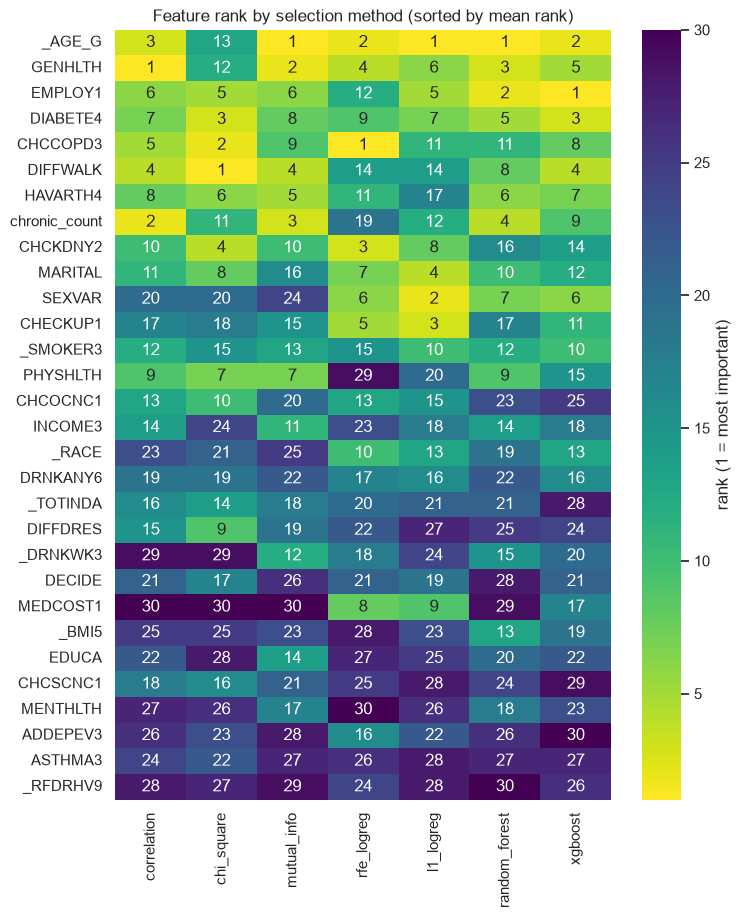

In [5]:
order = summary.index
plt.figure(figsize=(8, 10))
sns.heatmap(ranks.loc[order], annot=True, fmt=".0f", cmap="viridis_r",
            cbar_kws={"label": "rank (1 = most important)"})
plt.title("Feature rank by selection method (sorted by mean rank)")
plt.savefig("../reports/figures/06_feature_rank_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

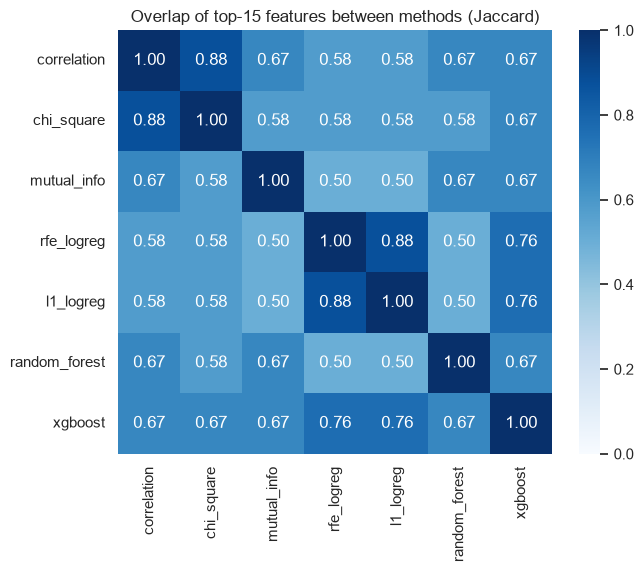

In [6]:
top = {m: set(ranks[m].nsmallest(15).index) for m in ranks.columns}
methods = list(top)
agree = pd.DataFrame(
    [[len(top[a] & top[b]) / len(top[a] | top[b]) for b in methods] for a in methods],
    index=methods, columns=methods)

plt.figure(figsize=(7, 5.5))
sns.heatmap(agree, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Overlap of top-15 features between methods (Jaccard)")
plt.savefig("../reports/figures/07_method_agreement.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
raw_ranked = [f for f in summary.index if f != "chronic_count"]
minimal = raw_ranked[:15]
full = raw_ranked                      # all 29 raw features

print("minimal (15 raw questions):", minimal)

json.dump({"full": full, "minimal": minimal, "derived_tested_separately": ["chronic_count"]},
          open("../reports/selected_features.json", "w"), indent=2)

minimal (15 raw questions): ['_AGE_G', 'GENHLTH', 'EMPLOY1', 'DIABETE4', 'CHCCOPD3', 'DIFFWALK', 'HAVARTH4', 'CHCKDNY2', 'MARITAL', 'SEXVAR', 'CHECKUP1', '_SMOKER3', 'PHYSHLTH', 'CHCOCNC1', 'INCOME3']


In [9]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t, correction=False)[0]
    return np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))

pairs = [(a, b, cramers_v(X_train[a], X_train[b]))
         for i, a in enumerate(minimal) for b in minimal[i + 1:]]
red = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "cramers_v"])
print(red.sort_values("cramers_v", ascending=False).head(10).round(2).to_string(index=False))

print("\nEmployment mix by age group (share of each age group):")
print(pd.crosstab(X_train["_AGE_G"], X_train["EMPLOY1"], normalize="index").round(2))

feature_a feature_b  cramers_v
  GENHLTH  DIFFWALK       0.45
 DIFFWALK  PHYSHLTH       0.44
  EMPLOY1  DIFFWALK       0.40
   _AGE_G  HAVARTH4       0.40
   _AGE_G   EMPLOY1       0.39
  EMPLOY1  HAVARTH4       0.36
 DIFFWALK  HAVARTH4       0.32
  GENHLTH  PHYSHLTH       0.32
   _AGE_G   MARITAL       0.28
 DIFFWALK   INCOME3       0.28

Employment mix by age group (share of each age group):
EMPLOY1   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0
_AGE_G                                                 
1.0      0.54  0.05  0.03  0.06  0.02  0.28  0.00  0.02
2.0      0.71  0.09  0.03  0.05  0.06  0.04  0.00  0.03
3.0      0.69  0.12  0.03  0.04  0.06  0.01  0.01  0.05
4.0      0.64  0.13  0.03  0.03  0.05  0.01  0.03  0.08
5.0      0.48  0.11  0.03  0.02  0.04  0.00  0.18  0.14
6.0      0.10  0.06  0.01  0.00  0.03  0.00  0.76  0.04


## Feature selection findings

Seven methods (correlation, chi-square, mutual information, RFE, L1 logistic regression, Random Forest and XGBoost importance) were run on the training set only, with encoded columns rolled up to the original features and ranks averaged across methods.

**Consensus.** Age group, self-rated general health, employment status, diabetes status, COPD and difficulty walking were in the top 15 for all seven methods, along with smoking status, which was the most stable (rank 10–15 everywhere). Arthritis, kidney disease and marital status followed, with mean ranks of 8.6–9.7.

**Weak features.** Heavy drinking, asthma, depression, mental-health days, skin cancer and BMI ranked lowest. After age, general health and chronic conditions, they add little signal in this data.

**Derived feature.** The chronic-condition count ranked 8th by mean rank, but requires seven questionnaire items, so the minimal set uses 15 raw questions only. Its contribution is tested separately in model comparison.

**Redundancy.** No pair of selected features is near-duplicate (highest Cramér's V = 0.45, general health vs difficulty walking). Employment status overlaps with age (about 76% of respondents aged 65+ are retired) but also carries information age does not, such as "unable to work" (14% at ages 55–64 vs 4% at 65+); its value beyond age is tested in an ablation.

**Limitation.** Selection used the whole training set and cross-validation is later run inside it, which makes CV estimates very slightly optimistic. The test set was not used.